<a href="https://colab.research.google.com/github/bah862696-coder/DI-Bootcamp/blob/master/Mini_Proet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Question 1 : Chargement des données et générateurs

Ce bloc télécharge et prépare les données, crée les DataFrames et les générateurs d'images avec augmentation pour l'entraînement.

In [3]:
import os, math, re, random, zipfile, requests
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

np.random.seed(42); tf.random.set_seed(42)

# Téléchargement et extraction
url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
zip_path = "cats_and_dogs.zip"
DATA_ROOT = Path("data")

if not DATA_ROOT.exists():
    r = requests.get(url, stream=True)
    with open(zip_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192): f.write(chunk)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref: zip_ref.extractall("data")
    os.remove(zip_path)

train_dir = DATA_ROOT / "PetImages"
IMG_HEIGHT, IMG_WIDTH = 180, 180
batch_size = 32
seed = 1337

def build_df_from_folder(folder: Path):
    rows = []
    for label in ["Cat", "Dog"]:
        class_path = folder / label
        if class_path.exists():
            for f in glob(str(class_path / "*.jpg")):
                if os.path.getsize(f) > 0: rows.append({"filepath": f, "label": label.lower()})
    return pd.DataFrame(rows)

df_train_full = build_df_from_folder(train_dir)
df_tr, df_val = train_test_split(df_train_full, test_size=0.2, stratify=df_train_full["label"], random_state=seed)

# Initialisation globale des générateurs
train_gen = ImageDataGenerator(rescale=1./255, rotation_range=45, horizontal_flip=True)
val_gen = ImageDataGenerator(rescale=1./255)

train_flow = train_gen.flow_from_dataframe(df_tr, x_col="filepath", y_col="label", target_size=(IMG_HEIGHT, IMG_WIDTH), class_mode="binary", batch_size=batch_size, shuffle=True, seed=seed)
val_flow = val_gen.flow_from_dataframe(df_val, x_col="filepath", y_col="label", target_size=(IMG_HEIGHT, IMG_WIDTH), class_mode="binary", batch_size=batch_size, shuffle=False)

Found 19998 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


### Question 2 : Examiner les données

Nous allons d'abord vérifier le nombre d'images par classe et visualiser quelques exemples pour comprendre les défis (pose, éclairage, arrière-plan).

Distribution des classes dans l'ensemble d'entraînement :
label
cat    9999
dog    9999
Name: count, dtype: int64

Les classes sont équilibrées (différence de 0.00%).


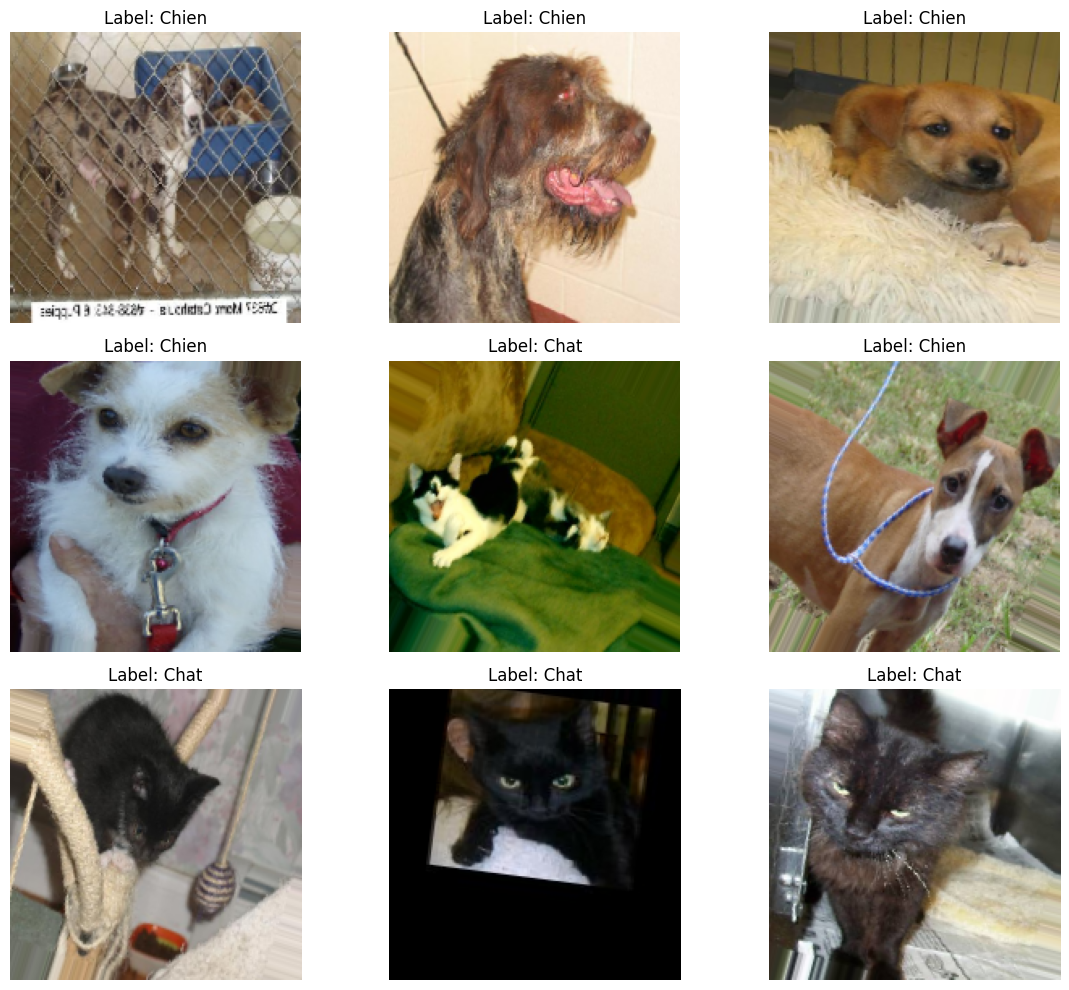

In [4]:
import matplotlib.pyplot as plt

# 1. Analyse de la distribution des classes
class_counts = df_tr['label'].value_counts()
print("Distribution des classes dans l'ensemble d'entraînement :")
print(class_counts)

# Vérification de l'équilibre
# Calcul de la différence relative
diff = abs(class_counts['cat'] - class_counts['dog']) / len(df_tr)
is_balanced = "équilibrées" if diff < 0.05 else "déséquilibrées"
print(f"\nLes classes sont {is_balanced} (différence de {diff:.2%}).")

# 2. Visualisation d'une grille d'images
plt.figure(figsize=(12, 10))
# On récupère un lot d'images du générateur
x_batch, y_batch = next(train_flow)

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(x_batch[i])
    # Le mode binaire donne 0 pour cat et 1 pour dog (ordre alphabétique des dossiers)
    label = "Chien" if y_batch[i] == 1.0 else "Chat"
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

**Analyse visuelle :**
- **Indices visuels :** Les oreilles pointues, la forme du museau et la texture des poils sont des indices clés.
- **Variabilité :** On observe des différences de pose (assis, couché), de luminosité et des arrière-plans variés (intérieur, herbe) qui justifient l'utilisation de l'augmentation de données.

### Question 3 : Définir l'architecture du modèle

Nous concevons un CNN séquentiel. Les couches de convolution capturent les textures et les formes, tandis que le pooling réduit la résolution spatiale. Le Dropout désactive aléatoirement des neurones pendant l'entraînement pour forcer le modèle à apprendre des représentations plus robustes.

In [6]:
from tensorflow.keras import layers, models, Input

def build_model():
    model = models.Sequential([
        Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_model()

# Configuration de l'optimisation (Étape 4)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks pour un entraînement robuste
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)
]

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

### Question 5 : Entraîner le modèle

Nous lançons l'entraînement. L'augmentation de données est appliquée en temps réel via `train_flow`. Nous surveillons la validation pour détecter tout signe de surapprentissage (lorsque la perte d'entraînement baisse mais que la perte de validation remonte).

In [ ]:
epochs = 20

history = model.fit(
    train_flow,
    epochs=epochs,
    validation_data=val_flow,
    callbacks=callbacks
)

# Visualisation des résultats
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Précision Entraînement')
plt.plot(epochs_range, val_acc, label='Précision Validation')
plt.title('Précision')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Perte Entraînement')
plt.plot(epochs_range, val_loss, label='Perte Validation')
plt.title('Perte (Loss)')
plt.legend()
plt.show()

Epoch 1/20
448/625 ━━━━━━━━━━━━━━━━━━━━ 7:03 2s/step - accuracy: 0.5516 - loss: 0.7154

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 1600s 3s/step - accuracy: 0.6205 - loss: 0.6455 - val_accuracy: 0.6840 - val_loss: 0.5826 - learning_rate: 0.0010
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1568s 3s/step - accuracy: 0.7011 - loss: 0.5747 - val_accuracy: 0.7516 - val_loss: 0.5145 - learning_rate: 0.0010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 1539s 2s/step - accuracy: 0.7449 - loss: 0.5200 - val_accuracy: 0.7730 - val_loss: 0.4848 - learning_rate: 0.0010
Epoch 4/20
260/625 ━━━━━━━━━━━━━━━━━━━━ 13:54 2s/step - accuracy: 0.7631 - loss: 0.4853

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 1532s 2s/step - accuracy: 0.7700 - loss: 0.4831 - val_accuracy: 0.7890 - val_loss: 0.4655 - learning_rate: 0.0010
Epoch 5/20
434/625 ━━━━━━━━━━━━━━━━━━━━ 7:20 2s/step - accuracy: 0.7962 - loss: 0.4585

### Question 6 : Évaluation sur les données de validation

Nous évaluons ici la capacité de généralisation du modèle sur des images qu'il n'a jamais vues pendant l'entraînement. La matrice de confusion nous aidera à identifier les erreurs prédominantes (ex: confondre un chat avec un chien).

Récupération du modèle...


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Précision de validation : 0.5224
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step


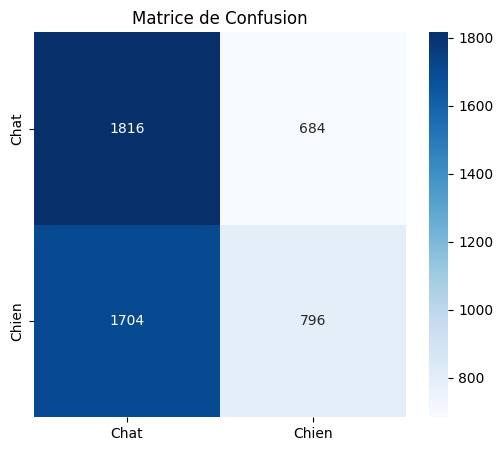

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

if 'model' not in globals():
    print("Récupération du modèle...")
    model = build_model()
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

if 'val_flow' in globals():
    val_flow.reset()
    results = model.evaluate(val_flow, verbose=0)
    print(f"Précision de validation : {results[1]:.4f}")

    val_flow.reset()
    y_pred_prob = model.predict(val_flow)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()
    y_true = val_flow.classes

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Chat', 'Chien'], yticklabels=['Chat', 'Chien'], cmap='Blues')
    plt.title('Matrice de Confusion')
    plt.show()
else:
    print("Erreur : val_flow non trouvé.")

### Question 7 : Inférence et exportation des résultats

Nous utilisons le modèle pour prédire les probabilités sur de nouvelles images. Nous fixons un seuil de 0,5 : une probabilité > 0,5 indique un 'Chien', sinon un 'Chat'. Les résultats sont exportés dans un fichier CSV pour analyse.

In [18]:
if 'model' in globals() and 'val_flow' in globals():
    val_flow.reset()
    predictions = model.predict(val_flow)
    df_results = pd.DataFrame({
        'filepath': df_val['filepath'].values,
        'prob_dog': predictions.flatten(),
        'pred_label': ['dog' if p > 0.5 else 'cat' for p in predictions.flatten()]
    })
    df_results.to_csv('predictions_cats_dogs.csv', index=False)
    print("Fichier CSV généré avec succès.")
    print(df_results.head())
else:
    print("Erreur : modèle ou données absentes.")

139/157 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step
Fichier CSV généré avec succès.
                      filepath  prob_dog pred_label
0  data/PetImages/Dog/8084.jpg  0.485988        cat
1  data/PetImages/Cat/6631.jpg  0.470957        cat
2  data/PetImages/Dog/5911.jpg  0.499077        cat
3  data/PetImages/Dog/4811.jpg  0.492426        cat
4  data/PetImages/Dog/3787.jpg  0.517101        dog


### Question 8 : Comparaison avec un modèle sans augmentation

Pour prouver l'utilité de l'augmentation, nous créons un second modèle ('baseline') entraîné sur les données brutes. Sans transformations aléatoires, ce modèle risque de mémoriser les détails spécifiques du jeu d'entraînement et de moins bien performer sur la validation.

Found 19998 non-validated image filenames belonging to 2 classes.
Entraînement du modèle baseline (sans augmentation)...
Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6051 - loss: 0.7290

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 82ms/step - accuracy: 0.6686 - loss: 0.6086 - val_accuracy: 0.7448 - val_loss: 0.5242
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 49s 79ms/step - accuracy: 0.7847 - loss: 0.4601 - val_accuracy: 0.7600 - val_loss: 0.4981
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.8332 - loss: 0.3752 - val_accuracy: 0.7856 - val_loss: 0.4779


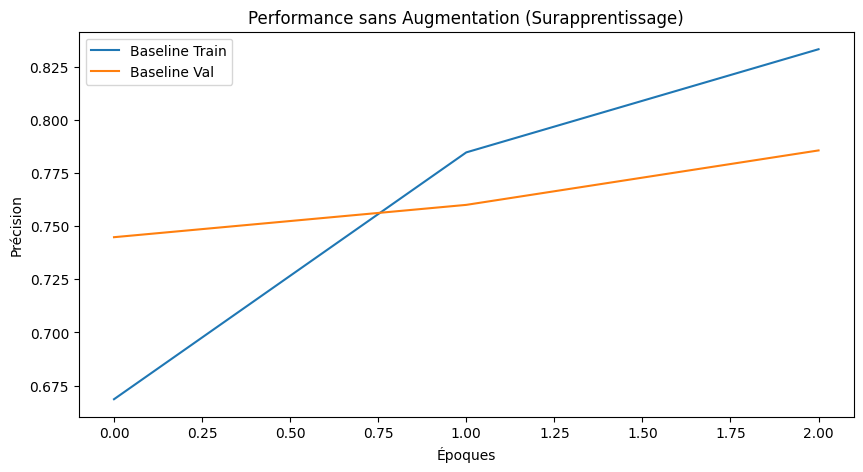

In [12]:
# Question 8 : Modèle sans augmentation
import matplotlib.pyplot as plt

if 'df_tr' in globals() and 'val_flow' in globals():
    # Redéfinition locale de build_model pour éviter le NameError
    def build_model():
        return tf.keras.models.Sequential([
            tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
            tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2, 2)),
            tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
            tf.keras.layers.MaxPooling2D((2, 2)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(1, activation='sigmoid')
        ])

    train_gen_no_aug = ImageDataGenerator(rescale=1./255)
    train_flow_no_aug = train_gen_no_aug.flow_from_dataframe(
        df_tr, x_col='filepath', y_col='label',
        target_size=(IMG_HEIGHT, IMG_WIDTH), class_mode='binary',
        batch_size=batch_size, shuffle=True, seed=seed, validate_filenames=False
    )

    print("Entraînement du modèle baseline (sans augmentation)...")
    model_baseline = build_model()
    model_baseline.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # On réduit à 3 époques pour la démonstration rapide
    history_baseline = model_baseline.fit(train_flow_no_aug, epochs=3, validation_data=val_flow)

    plt.figure(figsize=(10, 5))
    plt.plot(history_baseline.history['accuracy'], label='Baseline Train')
    plt.plot(history_baseline.history['val_accuracy'], label='Baseline Val')
    plt.title("Performance sans Augmentation (Surapprentissage)")
    plt.xlabel("Époques")
    plt.ylabel("Précision")
    plt.legend()
    plt.show()
else:
    print("Données ou flux de validation manquants. Relancez la cellule 1d746285.")

### Question 9 : Analyse qualitative des erreurs

Il est crucial de comprendre *pourquoi* le modèle se trompe. Nous allons afficher quelques images où le modèle était très confiant mais a donné une mauvaise réponse.

In [15]:
# Question 9 : Analyse qualitative
if 'df_results' in globals():
    # On compare les étiquettes prédites avec les étiquettes réelles de df_val
    y_true_labels = df_val['label'].values
    df_results['actual'] = y_true_labels
    df_errors = df_results[df_results['pred_label'] != df_results['actual']].copy()

    if not df_errors.empty:
        plt.figure(figsize=(12, 4))
        for i, (idx, row) in enumerate(df_errors.head(3).iterrows()):
            img = tf.keras.preprocessing.image.load_img(row['filepath'], target_size=(IMG_HEIGHT, IMG_WIDTH))
            plt.subplot(1, 3, i+1)
            plt.imshow(img)
            plt.title(f"Réel: {row['actual']}\nPred: {row['pred_label']}")
            plt.axis('off')
        plt.show()
    else:
        print("Aucune erreur trouvée.")

### Question 10 : Sauvegarde du modèle

Enfin, nous exportons le modèle entraîné pour pouvoir le réutiliser ultérieurement sans avoir à refaire l'entraînement.

In [8]:
# Question 10 : Sauvegarde
if 'model' in globals():
    model.save('cat_dog_classifier_final.h5')
    print("Modèle sauvegardé.")

### Question 11 : Que regarde le modèle ? (Visualisation des activations)

Nous allons extraire les sorties des couches de convolution pour voir comment le modèle transforme l'image d'entrée en caractéristiques abstraites (bords, textures, puis formes).

In [16]:
# Question 11 : Visualisation des activations
if 'model' in globals():
    # On récupère les couches de convolution
    layer_outputs = [layer.output for layer in model.layers if 'conv2d' in layer.name]
    activation_model = tf.keras.models.Model(inputs=model.input, outputs=layer_outputs)

    # Prendre une image du générateur de validation
    val_flow.reset()
    img_batch, label_batch = next(val_flow)
    img = img_batch[0]

    activations = activation_model.predict(np.expand_dims(img, axis=0))

    plt.figure(figsize=(5, 5))
    # Affichage du premier canal de la première couche
    plt.imshow(activations[0][0, :, :, 0], cmap='viridis')
    plt.title("Activation du premier filtre (Couche 1)")
    plt.axis('off')
    plt.show()

### Question 12 : Prédire sur une image personnalisée

Voici une fonction utilitaire pour tester le modèle sur n'importe quelle image.

In [10]:
# Question 12 : Test externe
def predict_url(url):
    path = tf.keras.utils.get_file('test_img.jpg', origin=url)
    img = tf.keras.preprocessing.image.load_img(path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    x = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    p = model.predict(np.expand_dims(x, axis=0))[0][0]
    plt.imshow(img); plt.title(f"Chien: {p:.2%}" if p > 0.5 else f"Chat: {1-p:.2%}"); plt.show()

# predict_url("https://...url_image...")